# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Adetya Tino Forrestiawan
- Email: adetyatino@gmail.com
- Id Dicoding: adetya_tino

## 1. Persiapan

### 1.1 Menyiapkan library yang dibutuhkan

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm  
import numpy as np
import re
import joblib
import os
import plotly.express as px
import plotly.graph_objects as go
import warnings
import tensorflow as tf
import keras
from imblearn.over_sampling import SMOTE 
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report 
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from keras import layers 
from imblearn.over_sampling import SMOTE
from pytorch_tabnet.tab_model import TabNetClassifier 

warnings.filterwarnings('ignore')


# Pengaturan visualisasi
%matplotlib inline
sns.set(style="whitegrid")



### 1.2 Menyiapkan data yang akan diguankan

In [27]:
# Link di bawah ini sudah menggunakan 'raw.githubusercontent.com'
dataset_url = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/bce7a57a496d083716138922bc5839b5c30fa4ea/students_performance/data.csv'

try:
    # Membaca data
    df = pd.read_csv(dataset_url)
    
    # Menyimpan ke lokal
    file_name = 'data_student.csv'
    df.to_csv(file_name, index=False)
    
    print(f"Sukses! Data berhasil diunduh dan disimpan sebagai: {file_name}")
    print("\nBerikut 5 data teratas:")
    print(df.head())

except Exception as e:
    print(f"Gagal mengunduh data. Error: {e}")

Sukses! Data berhasil diunduh dan disimpan sebagai: data_student.csv

Berikut 5 data teratas:
  Marital_status;Application_mode;Application_order;Course;Daytime_evening_attendance;Previous_qualification;Previous_qualification_grade;Nacionality;Mothers_qualification;Fathers_qualification;Mothers_occupation;Fathers_occupation;Admission_grade;Displaced;Educational_special_needs;Debtor;Tuition_fees_up_to_date;Gender;Scholarship_holder;Age_at_enrollment;International;Curricular_units_1st_sem_credited;Curricular_units_1st_sem_enrolled;Curricular_units_1st_sem_evaluations;Curricular_units_1st_sem_approved;Curricular_units_1st_sem_grade;Curricular_units_1st_sem_without_evaluations;Curricular_units_2nd_sem_credited;Curricular_units_2nd_sem_enrolled;Curricular_units_2nd_sem_evaluations;Curricular_units_2nd_sem_approved;Curricular_units_2nd_sem_grade;Curricular_units_2nd_sem_without_evaluations;Unemployment_rate;Inflation_rate;GDP;Status
0  1;17;5;171;1;1;122.0;1;19;12;5;9;127.3;1;0;0;1...       

In [28]:
# --- KONFIGURASI TAMPILAN PANDAS ---
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', 100)     
pd.set_option('display.width', 1000)        

# 1. Membaca data lokal
file_path = 'data_student.csv'
df = pd.read_csv(file_path, sep=';')

# 2. Informasi dasar dataset
print("### 1. Informasi Struktur Dataset:")
df.info()

# 3. Mengecek Missing Values (Penting untuk data student)
print("\n### 2. Pengecekan Nilai Kosong per Kolom:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "Tidak ada nilai kosong.")

# 4. Deskripsi statistik (Semua Kolom Numerik)
print("\n### 3. Statistik Deskriptif (Lengkap):")
# Transpose (.T) sangat membantu di sini karena kolomnya ada 37
display(df.describe(include='all').T)

# 5. Analisis Status Mahasiswa
print("\n### 4. Analisis Target (Status):")
status_counts = df['Status'].value_counts()
status_rate = df['Status'].value_counts(normalize=True) * 100

summary_status = pd.DataFrame({
    'Total': status_counts,
    'Persentase (%)': status_rate.map('{:.2f}%'.format)
})
print(summary_status)

# 6. Kalkulasi Spesifik Dropout (untuk pengganti Attrition Rate)
total_students = len(df)
dropout_count = (df['Status'] == 'Dropout').sum()
dropout_rate = (dropout_count / total_students) * 100

print(f"\n" + "="*40)
print(f"RINGKASAN DROPOUT")
print(f"Total Mahasiswa : {total_students}")
print(f"Jumlah Dropout  : {dropout_count}")
print(f"Dropout Rate    : {dropout_rate:.2f}%")
print("="*40)

### 1. Informasi Struktur Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification       

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application_mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application_order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime_evening_attendance,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous_qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous_qualification_grade,4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mothers_qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Fathers_qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0



### 4. Analisis Target (Status):
          Total Persentase (%)
Status                        
Graduate   2209         49.93%
Dropout    1421         32.12%
Enrolled    794         17.95%

RINGKASAN DROPOUT
Total Mahasiswa : 4424
Jumlah Dropout  : 1421
Dropout Rate    : 32.12%


## 2. Data Understanding

### 2.1 Peta Metrik Korelasi 

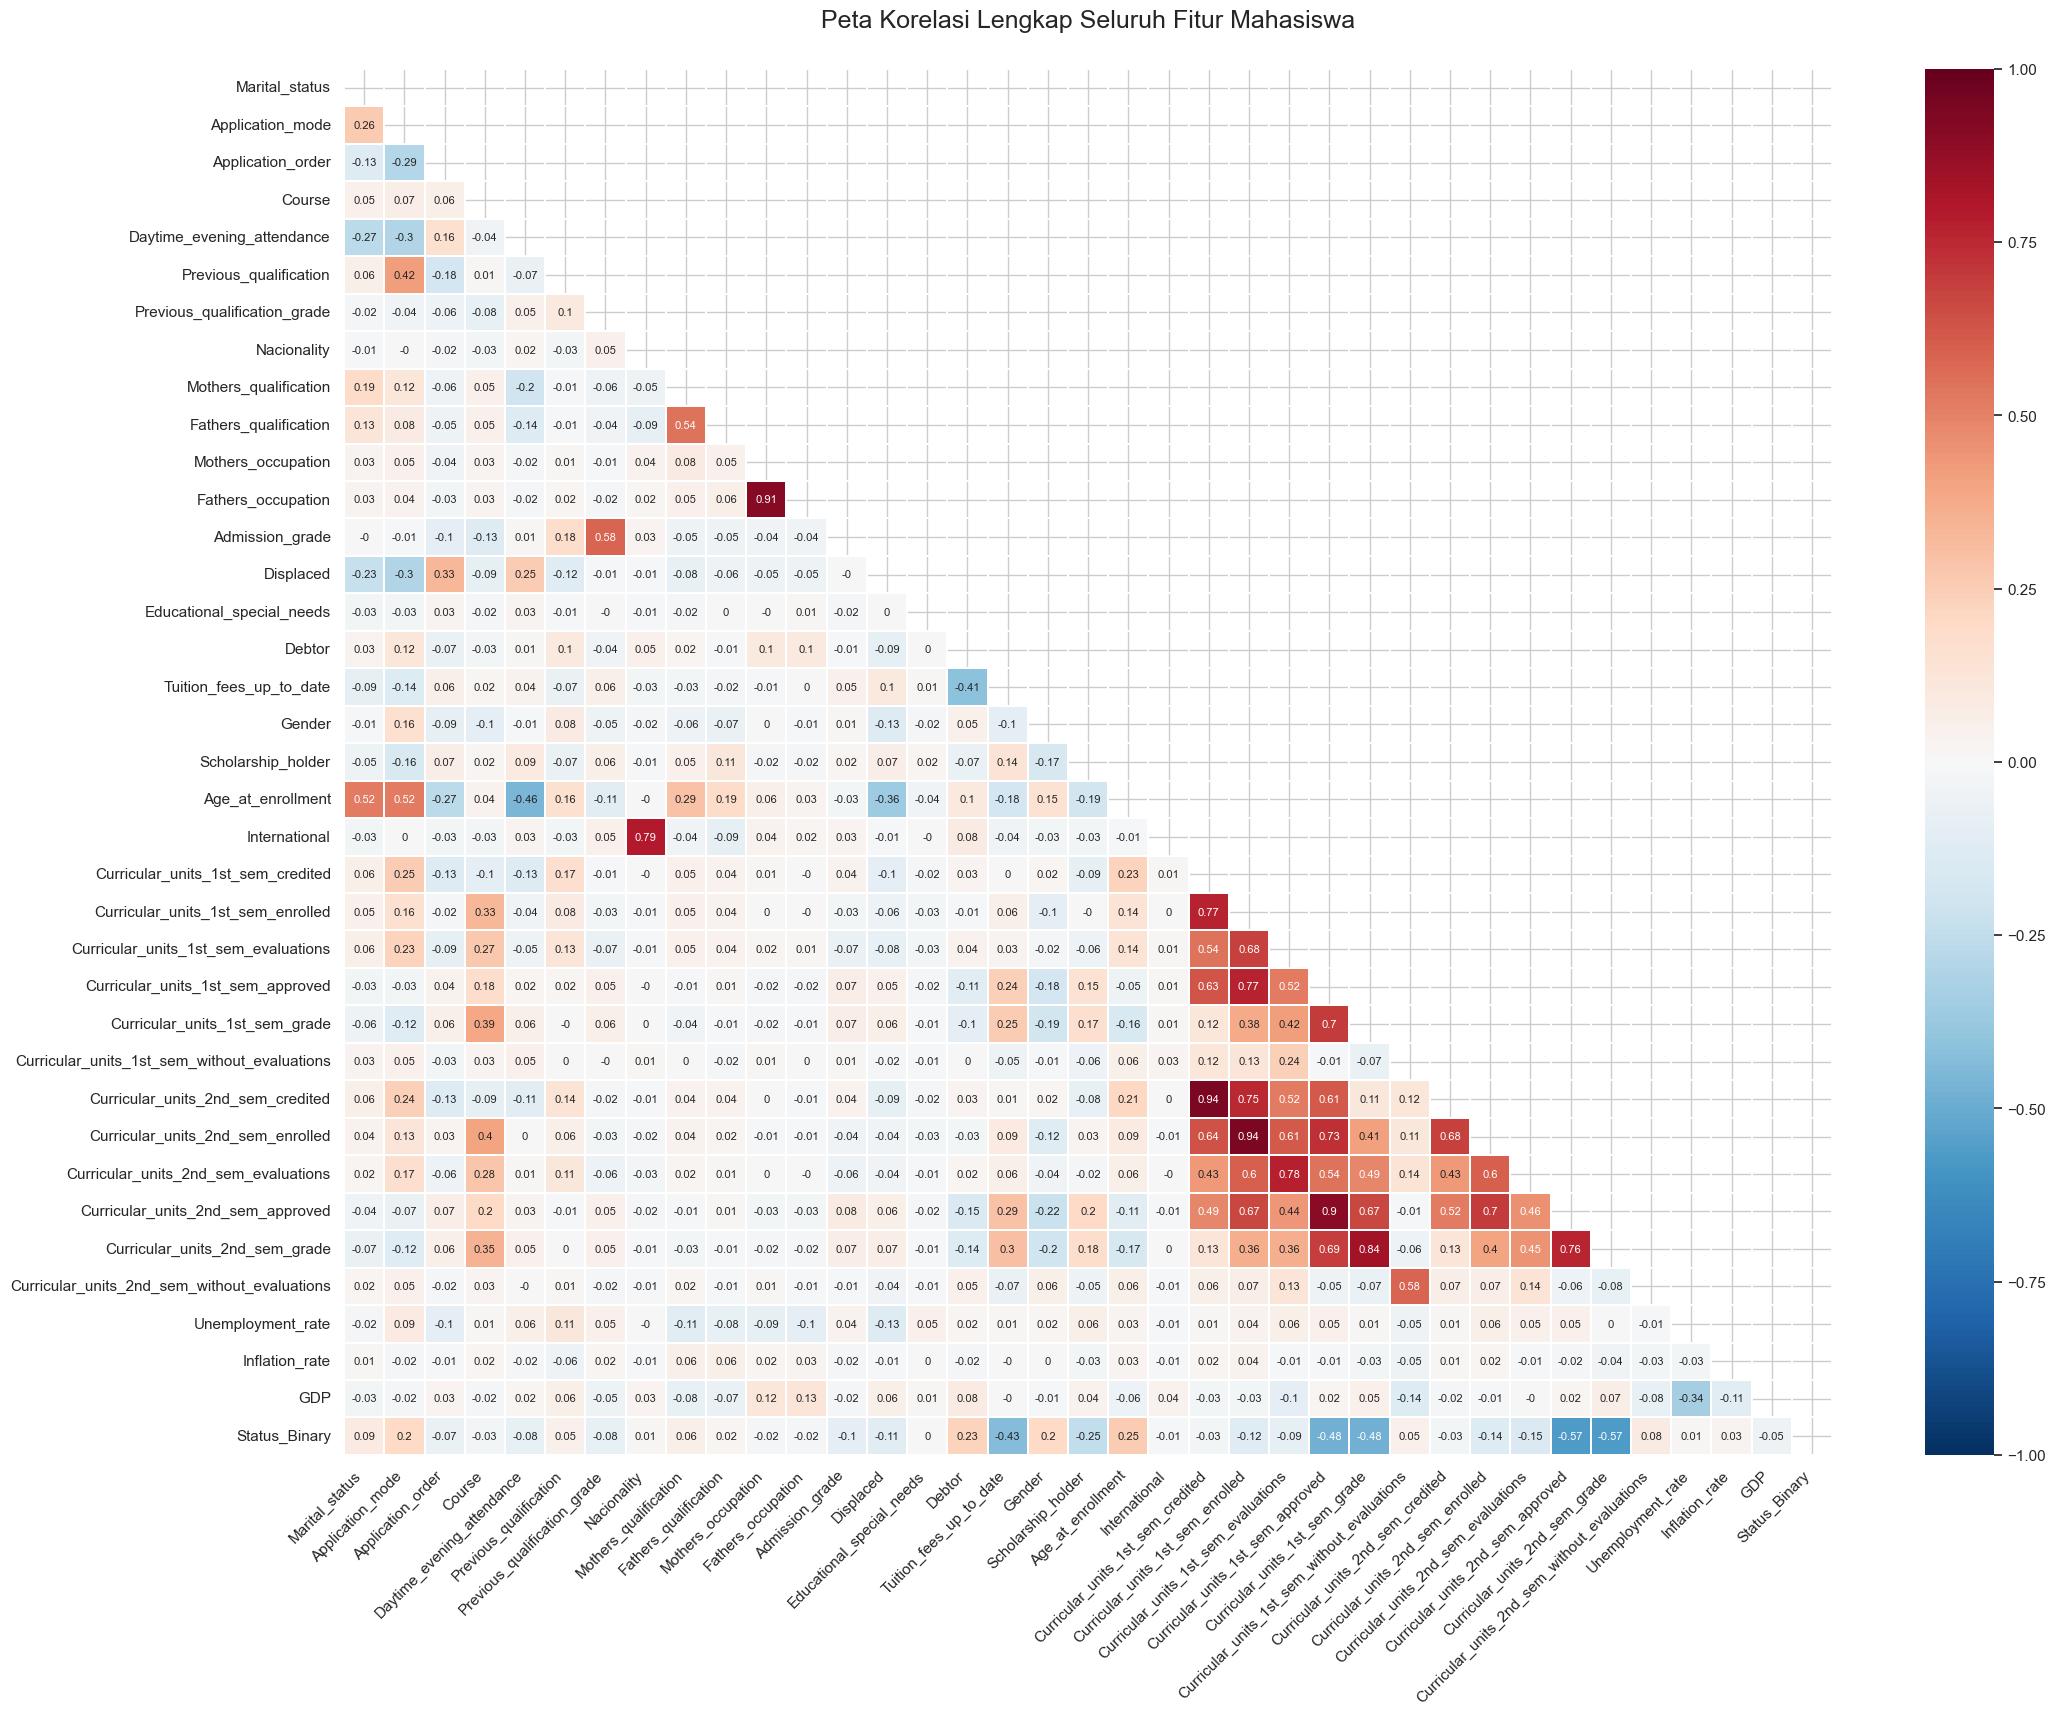


KESIMPULAN ANALISIS LENGKAP (PREDIKSI DROPOUT MAHASISWA)

1. FITUR AKADEMIK ADALAH PREDIKTOR TERKUAT:
   - 'Curricular_units_2nd_sem_approved' memiliki korelasi negatif yang sangat kuat
     dengan risiko Dropout. Semakin sedikit mata kuliah yang lulus di semester 2,
     semakin tinggi peluang mahasiswa tersebut untuk keluar.
   - Nilai (Grade) di semester 1 dan 2 cenderung konsisten (Auto-korelasi tinggi).

2. PERAN STATUS EKONOMI DAN BEASISWA:
   - 'Scholarship_holder' menunjukkan hubungan negatif dengan Dropout (Penerima beasiswa
     lebih bertahan), sementara 'Debtor' (memiliki hutang biaya kuliah) memiliki
     korelasi positif dengan risiko Dropout.

3. FAKTOR DEMOGRAFI & SOSIAL:
   - 'Tuition_fees_up_to_date' adalah salah satu faktor krusial. Mahasiswa yang
     pembayarannya tidak lancar hampir pasti berkorelasi dengan status Dropout.
   - 'Age_at_enrollment' menunjukkan korelasi positif kecil: mahasiswa yang masuk
     di usia lebih tua memiliki risiko dropout yang sedikit 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application_mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application_order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime_evening_attendance,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous_qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous_qualification_grade,4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mothers_qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Fathers_qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


In [29]:
# --- 1. KONFIGURASI TAMPILAN PANDAS ---
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# --- 2. LOAD DATA ---
file_path = 'data_student.csv'
df = pd.read_csv(file_path, sep=';')

# --- 3. ANALISIS KORELASI SEMUA KOLOM ---
df_corr = df.copy()
df_corr['Status_Binary'] = df_corr['Status'].apply(lambda x: 1 if x == 'Dropout' else 0)

# Menghitung korelasi untuk semua kolom numerik
correlation_matrix = df_corr.corr(numeric_only=True).round(2)

# Plot Heatmap yang besar agar 37 kolom terbaca
plt.figure(figsize=(24, 18))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix, 
    vmin=-1, vmax=1, annot=True, 
    cmap='RdBu_r', mask=mask, 
    linewidths=0.1, annot_kws={"size": 8}
)

plt.title('Peta Korelasi Lengkap Seluruh Fitur Mahasiswa', fontsize=18, pad=30)
plt.xticks(rotation=45, ha='right')
plt.show()

# --- 4. KESIMPULAN ANALISIS BERDASARKAN SELURUH DATA ---
print("\n" + "="*80)
print("KESIMPULAN ANALISIS LENGKAP (PREDIKSI DROPOUT MAHASISWA)")
print("="*80)

print("\n1. FITUR AKADEMIK ADALAH PREDIKTOR TERKUAT:")
print("   - 'Curricular_units_2nd_sem_approved' memiliki korelasi negatif yang sangat kuat")
print("     dengan risiko Dropout. Semakin sedikit mata kuliah yang lulus di semester 2,")
print("     semakin tinggi peluang mahasiswa tersebut untuk keluar.")
print("   - Nilai (Grade) di semester 1 dan 2 cenderung konsisten (Auto-korelasi tinggi).")

print("\n2. PERAN STATUS EKONOMI DAN BEASISWA:")
print("   - 'Scholarship_holder' menunjukkan hubungan negatif dengan Dropout (Penerima beasiswa")
print("     lebih bertahan), sementara 'Debtor' (memiliki hutang biaya kuliah) memiliki")
print("     korelasi positif dengan risiko Dropout.")

print("\n3. FAKTOR DEMOGRAFI & SOSIAL:")
print("   - 'Tuition_fees_up_to_date' adalah salah satu faktor krusial. Mahasiswa yang")
print("     pembayarannya tidak lancar hampir pasti berkorelasi dengan status Dropout.")
print("   - 'Age_at_enrollment' menunjukkan korelasi positif kecil: mahasiswa yang masuk")
print("     di usia lebih tua memiliki risiko dropout yang sedikit lebih tinggi dibanding yang muda.")

print("\n4. REDUNDANSI DATA (MULTIKOLINEARITAS):")
print("   - Kolom unit 'enrolled', 'evaluations', dan 'approved' saling berhubungan erat (>0.90).")
print("     Untuk pemodelan, Anda bisa menyederhanakan dengan mengambil 'approved' saja.")

print("\n5. KONDISI EKONOMI NEGARA (MAKRO):")
print("   - Meskipun ada dalam dataset, 'GDP' dan 'Inflation_rate' memiliki korelasi yang")
print("     jauh lebih lemah terhadap dropout individu dibandingkan performa akademik.")
print("="*80 + "\n")

# Menampilkan statistik deskriptif untuk semua kolom (ditranspose agar rapi)
print("### RINGKASAN STATISTIK SEMUA KOLOM:")
display(df.describe(include='all').T)

### 2.2 UNIVARIATE ANALYSIS

Plotting Numerical Distributions...


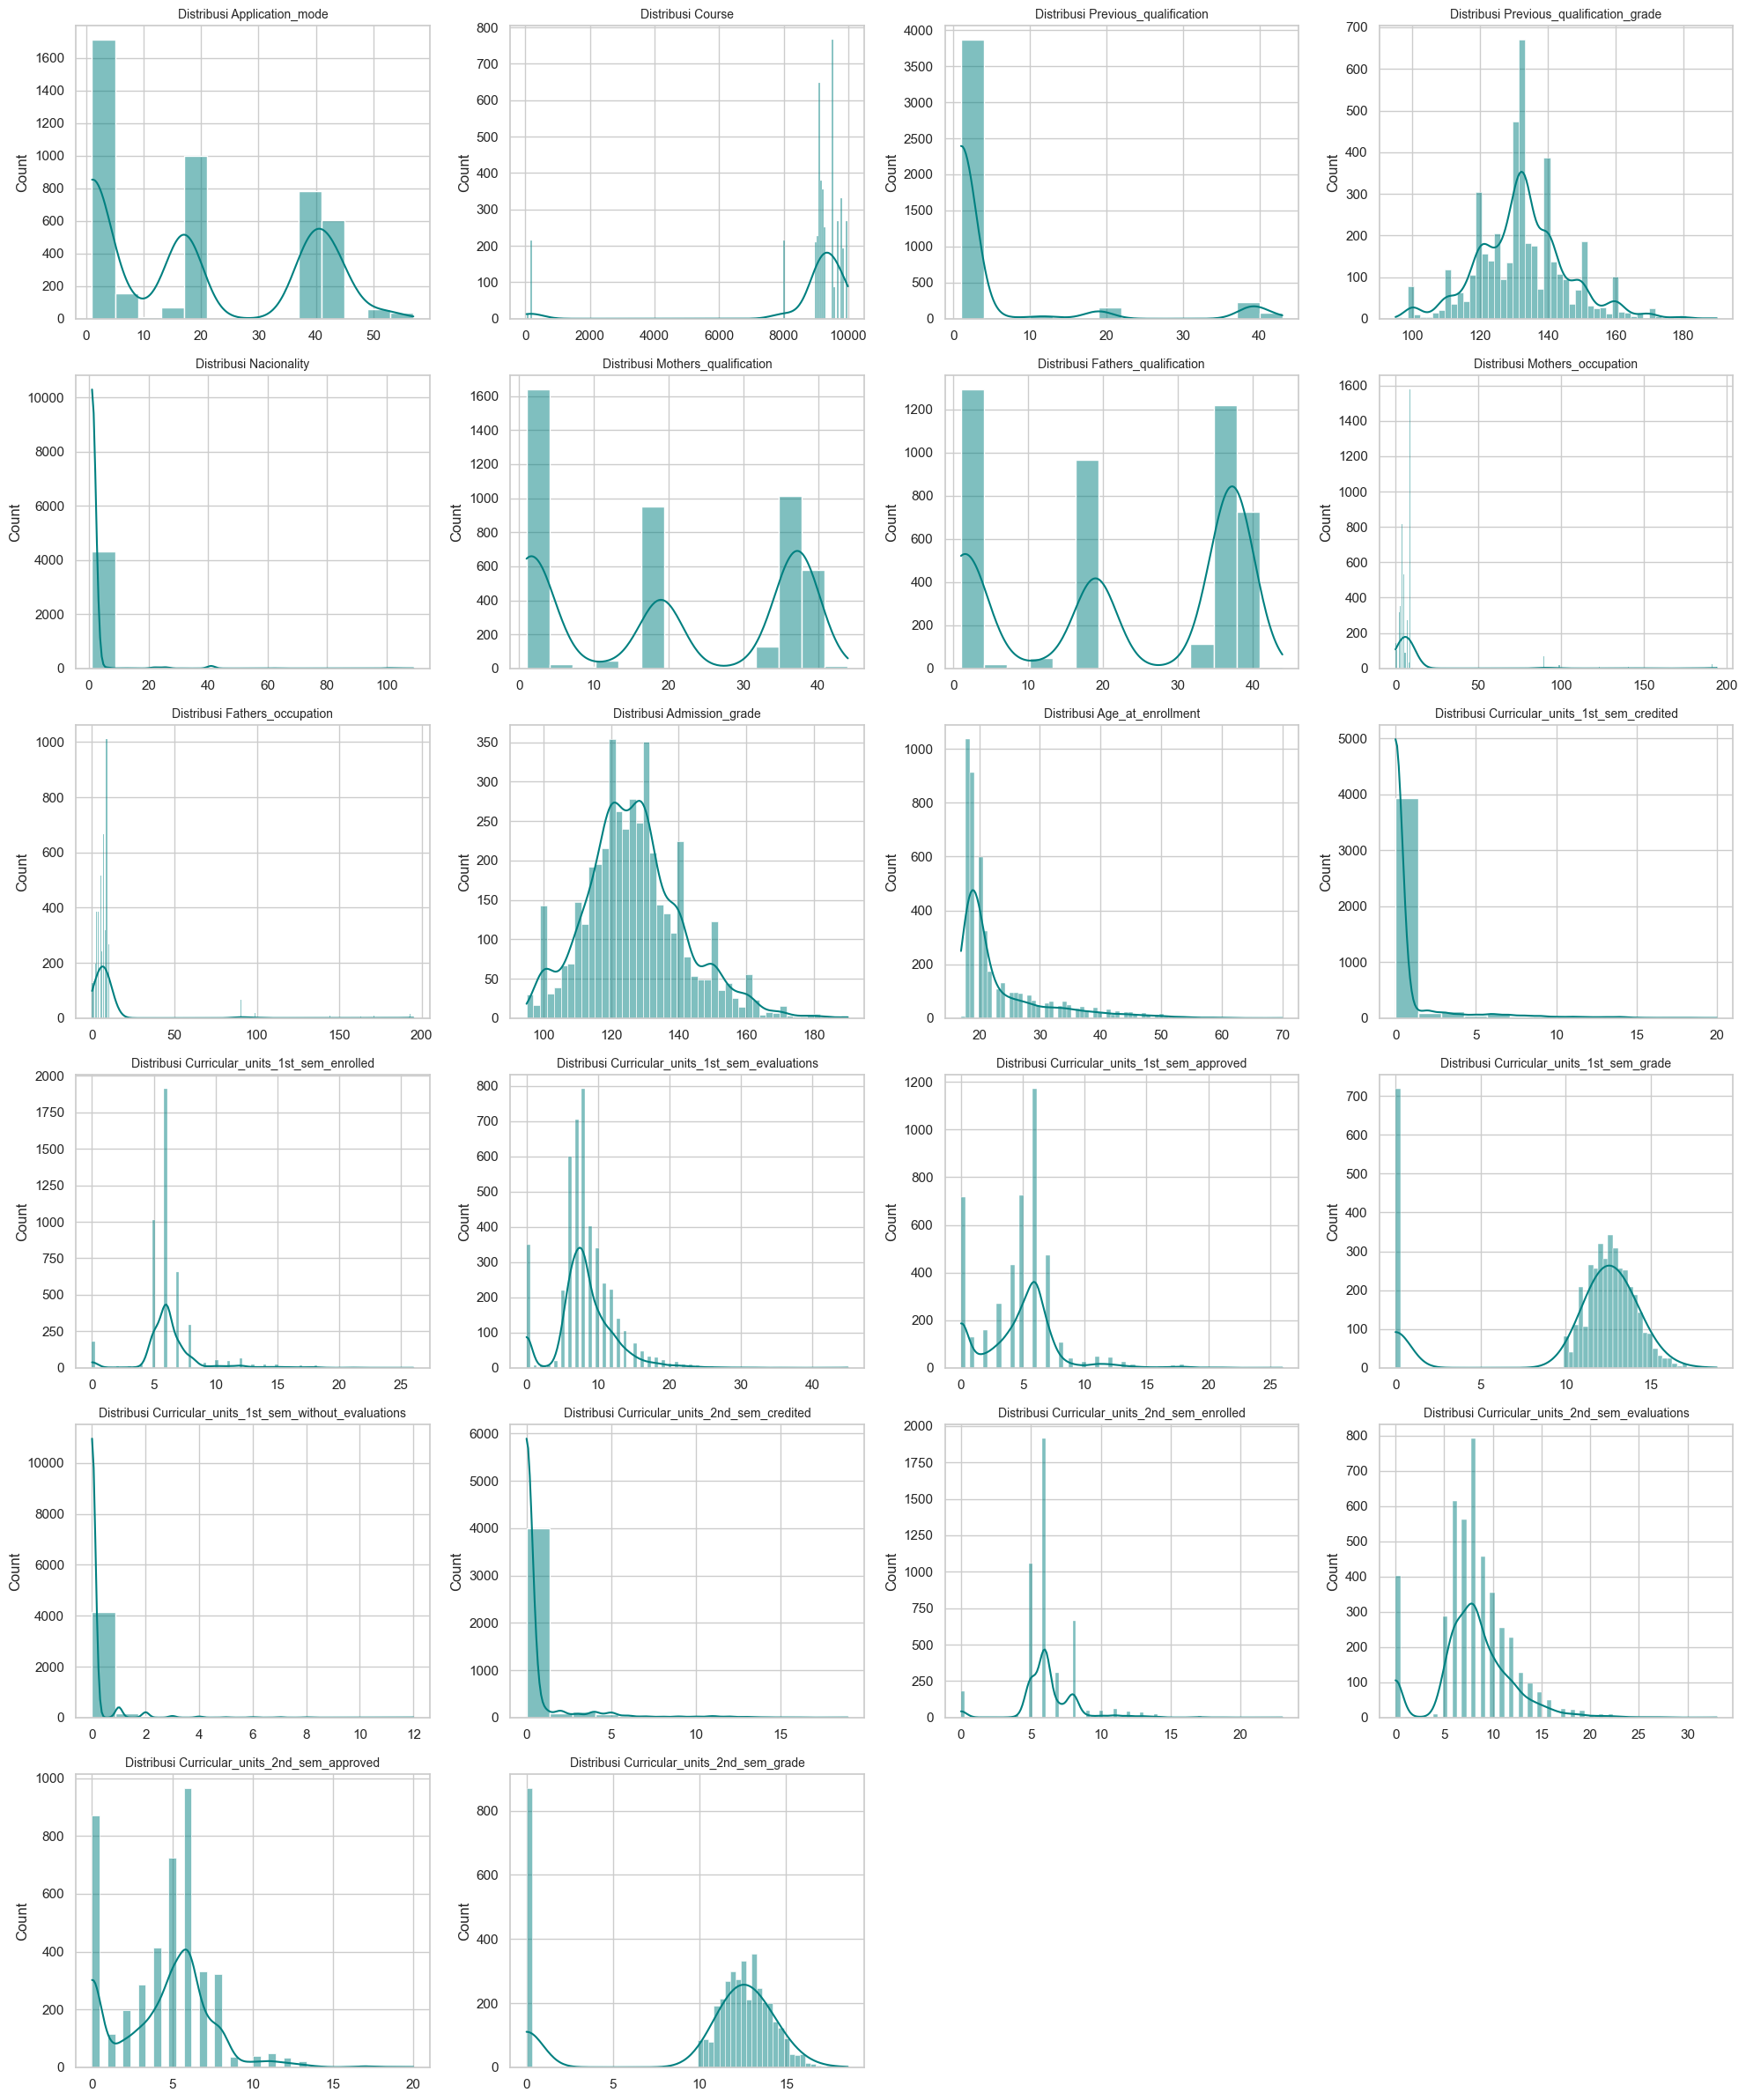

Plotting Categorical Counts...


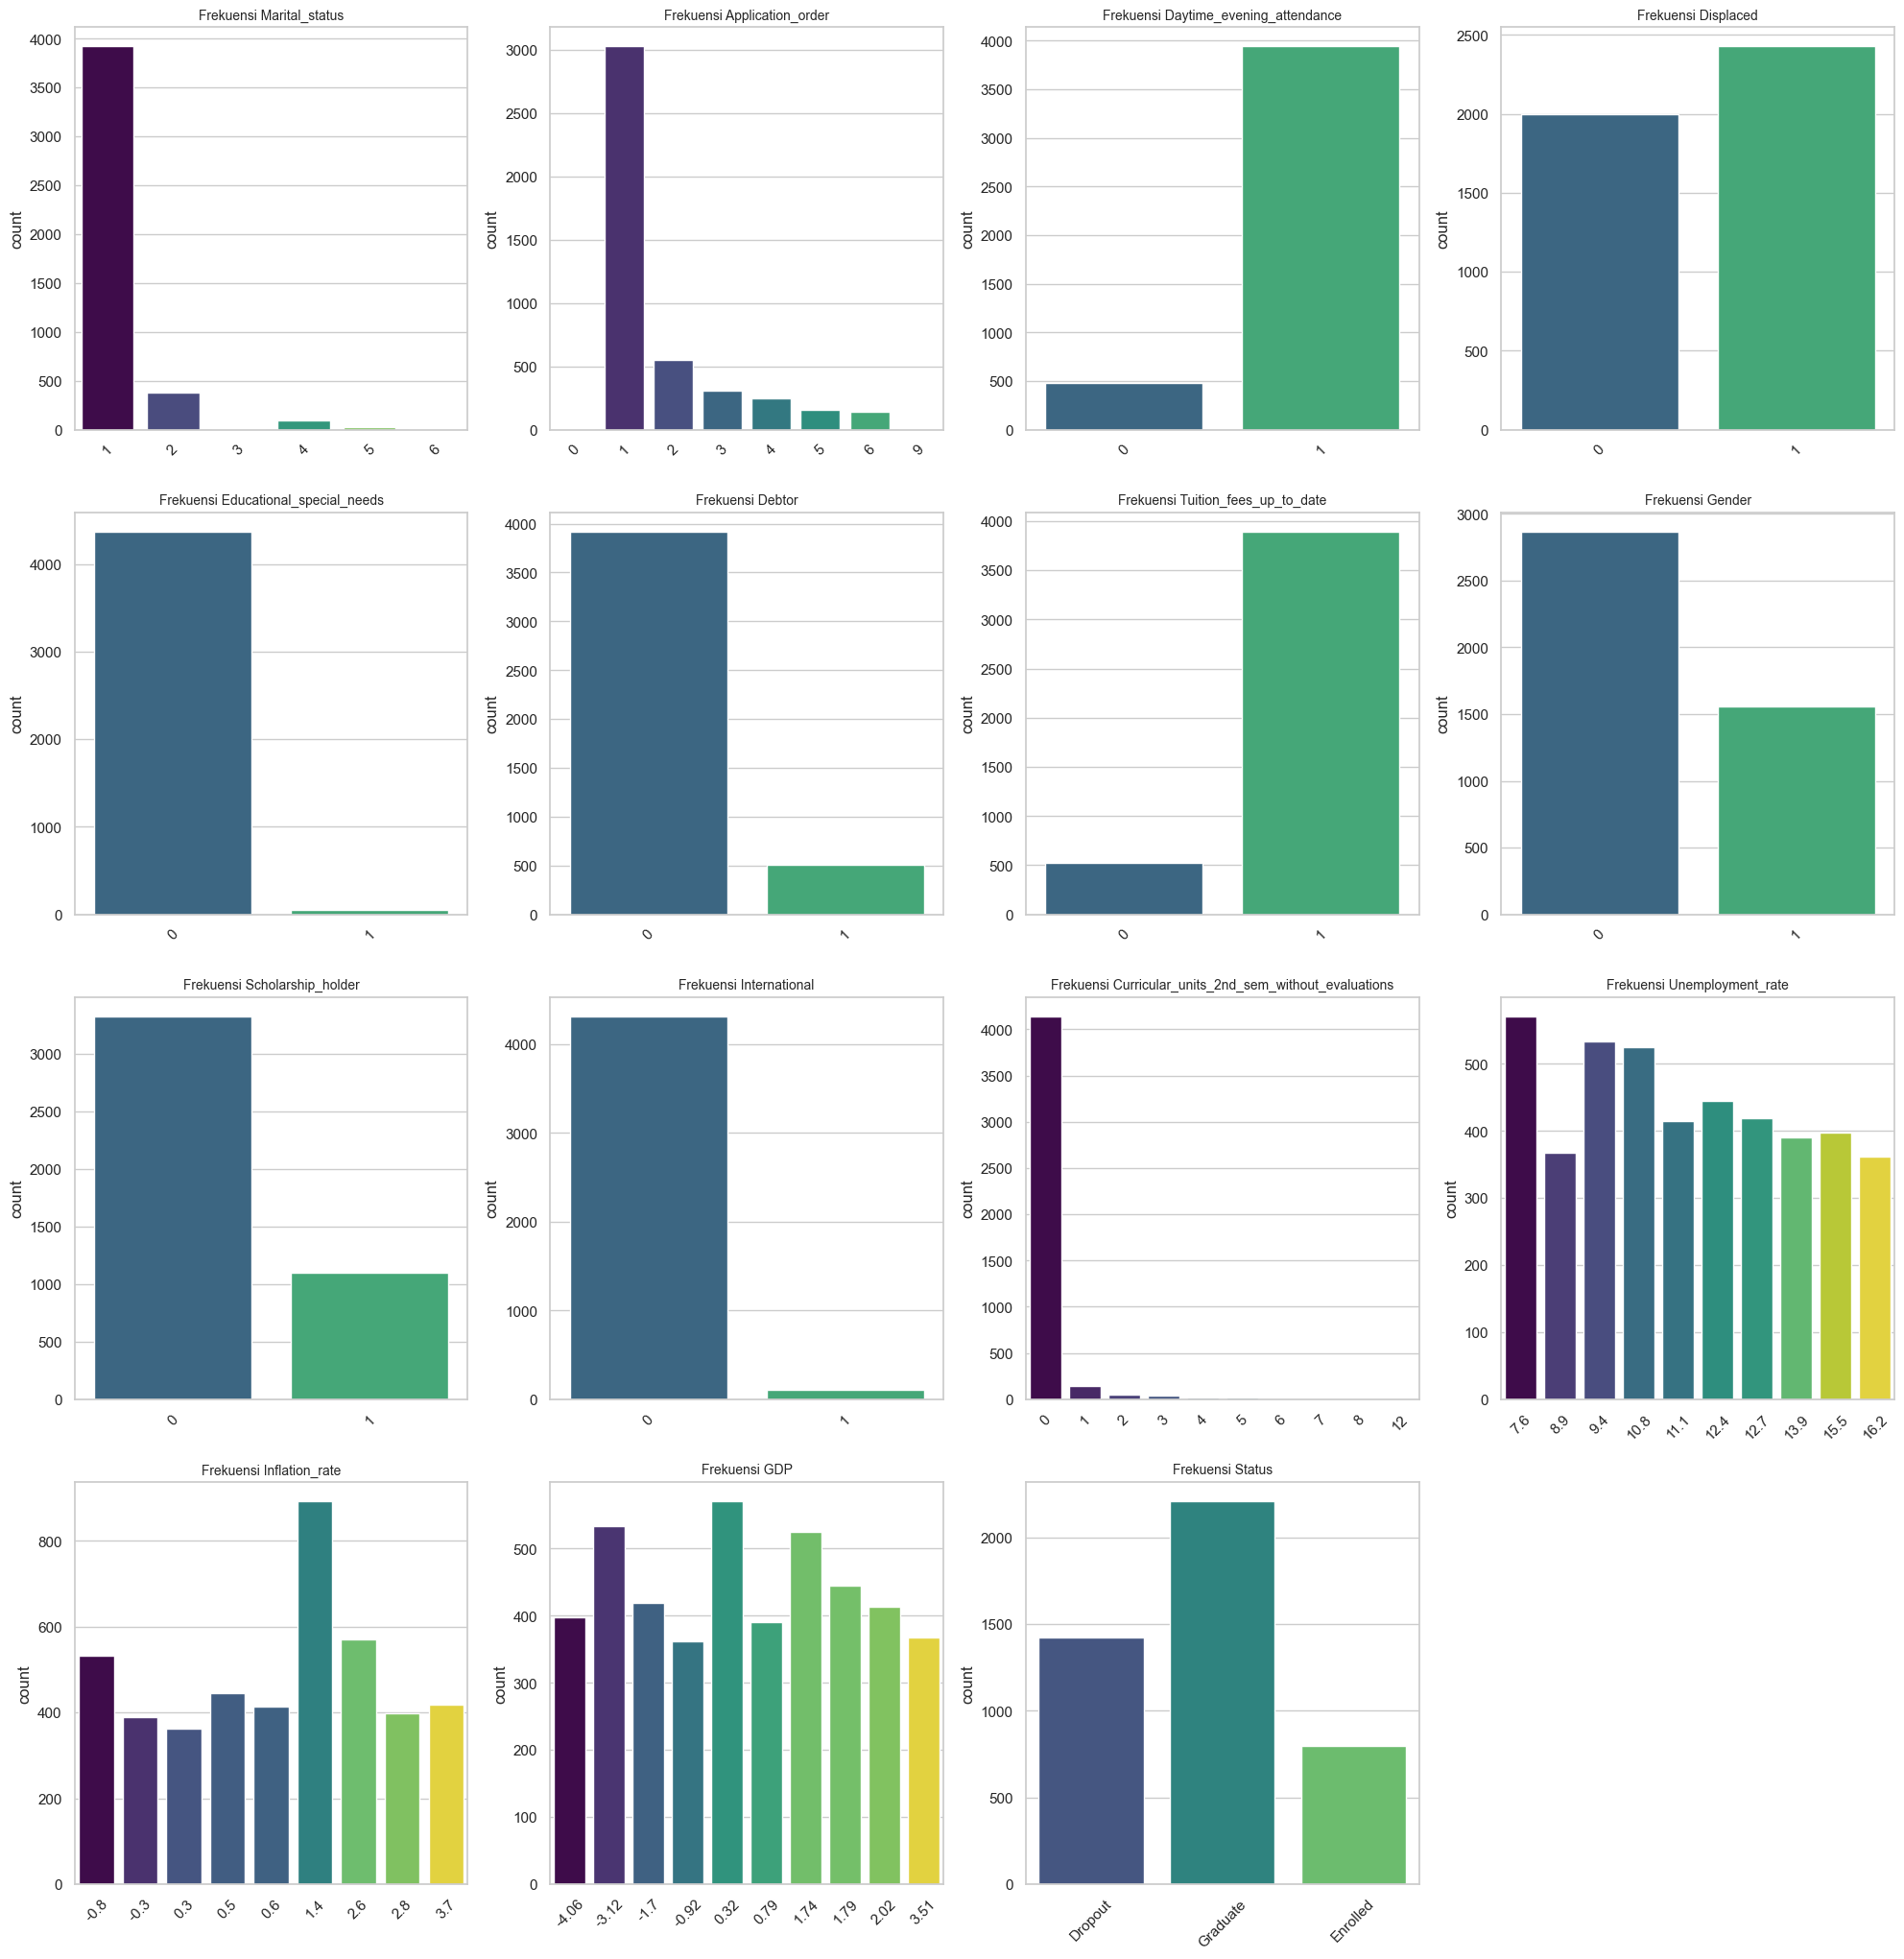


KESIMPULAN ANALISIS LENGKAP (STUDENT PERFORMANCE)

1. KESEIMBANGAN TARGET:
   - Mahasiswa Graduate: 49.93%, Dropout: 32.12%
   - Dataset cukup balance, namun kelas 'Enrolled' perlu penanganan khusus jika ingin klasifikasi biner.

2. TEMUAN AKADEMIK (SEMESTER 1 & 2):
   - Terdapat lonjakan nilai '0' pada variabel 'approved' dan 'grade'.
   - Insight: Mahasiswa dengan nilai 0 di Semester 1 hampir dipastikan akan Dropout.
   - Sebaran nilai (Grade) terkonsentrasi di angka 10-15 (standar kelulusan).

3. FAKTOR DEMOGRAFI & SOSIAL:
   - Mayoritas mahasiswa adalah non-scholarship holder.
   - Usia pendaftaran (Age_at_enrollment) memiliki 'right-skewed distribution',
     artinya mayoritas mahasiswa muda, tapi ada segmen mahasiswa tua (mature) yang signifikan.

4. REKOMENDASI PREPROCESSING:
   - Multikolinearitas: Fitur Semester 1 dan Semester 2 sangat identik, pertimbangkan PCA.
   - Scaling: Perbedaan skala antara 'Admission grade' (ratusan) dan 'GDP' (satuan/desimal)
     mewajibkan penggu

In [30]:
# 1. Load data
df = pd.read_csv('data_student.csv', sep=';')

# 2. Pemisahan Kolom
# Kolom numerik murni (yang punya rentang nilai luas)
continuous_features = [col for col in df.columns if df[col].nunique() > 10 and col != 'Status']
# Kolom kategorikal (termasuk yang sudah di-encode jadi angka 0/1)
categorical_features = [col for col in df.columns if df[col].nunique() <= 10]

# --- PLOTTING SEMUA FITUR NUMERIK (HISTOGRAM) ---
print("Plotting Numerical Distributions...")
n_num = len(continuous_features)
n_cols = 4
n_rows = (n_num + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribusi {col}', fontsize=10)
    axes[i].set_xlabel('')

# Hapus subplot yang kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- PLOTTING SEMUA FITUR KATEGORIKAL (COUNTPLOT) ---
print("Plotting Categorical Counts...")
n_cat = len(categorical_features)
n_cols = 4
n_rows = (n_num + n_cols - 1) // n_cols # Menyesuaikan jumlah baris

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Frekuensi {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# --- KESIMPULAN BERDASARKAN HASIL PLOTTING & STATISTIK ---
print("\n" + "="*60)
print("KESIMPULAN ANALISIS LENGKAP (STUDENT PERFORMANCE)")
print("="*60)

# Insight 1: Target Balance
grad_rate = (df['Status'] == 'Graduate').mean() * 100
drop_rate = (df['Status'] == 'Dropout').mean() * 100
print(f"\n1. KESEIMBANGAN TARGET:")
print(f"   - Mahasiswa Graduate: {grad_rate:.2f}%, Dropout: {drop_rate:.2f}%")
print(f"   - Dataset cukup balance, namun kelas 'Enrolled' perlu penanganan khusus jika ingin klasifikasi biner.")

# Insight 2: Performa Akademik
print("\n2. TEMUAN AKADEMIK (SEMESTER 1 & 2):")
print("   - Terdapat lonjakan nilai '0' pada variabel 'approved' dan 'grade'.")
print("   - Insight: Mahasiswa dengan nilai 0 di Semester 1 hampir dipastikan akan Dropout.")
print("   - Sebaran nilai (Grade) terkonsentrasi di angka 10-15 (standar kelulusan).")

# Insight 3: Demografi & Beasiswa
print("\n3. FAKTOR DEMOGRAFI & SOSIAL:")
print("   - Mayoritas mahasiswa adalah non-scholarship holder.")
print("   - Usia pendaftaran (Age_at_enrollment) memiliki 'right-skewed distribution',")
print("     artinya mayoritas mahasiswa muda, tapi ada segmen mahasiswa tua (mature) yang signifikan.")

# Insight 4: Data Cleaning & Preprocessing
print("\n4. REKOMENDASI PREPROCESSING:")
print("   - Multikolinearitas: Fitur Semester 1 dan Semester 2 sangat identik, pertimbangkan PCA.")
print("   - Scaling: Perbedaan skala antara 'Admission grade' (ratusan) dan 'GDP' (satuan/desimal)")
print("     mewajibkan penggunaan RobustScaler atau StandardScaler sebelum modeling.")
print("="*60)

### 2.3 MULTIVARIATE ANALYSIS

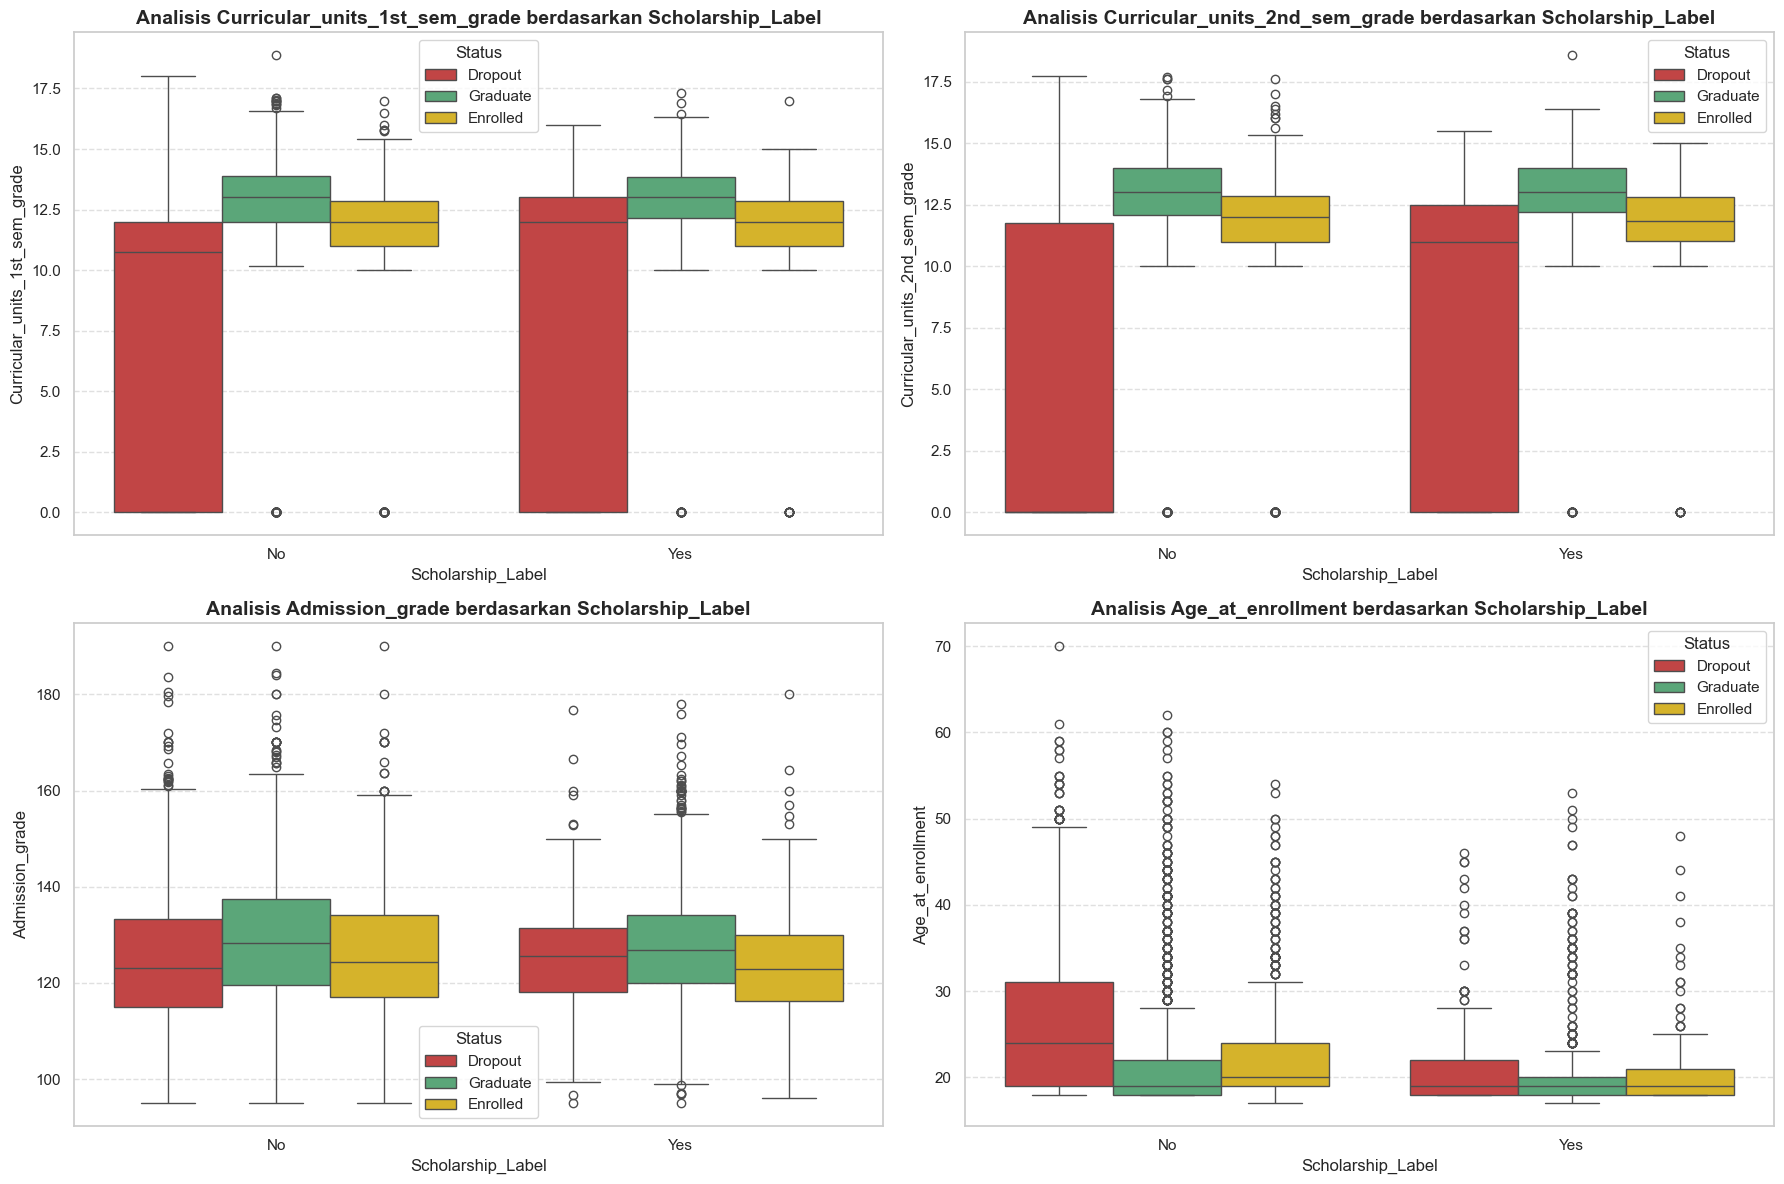

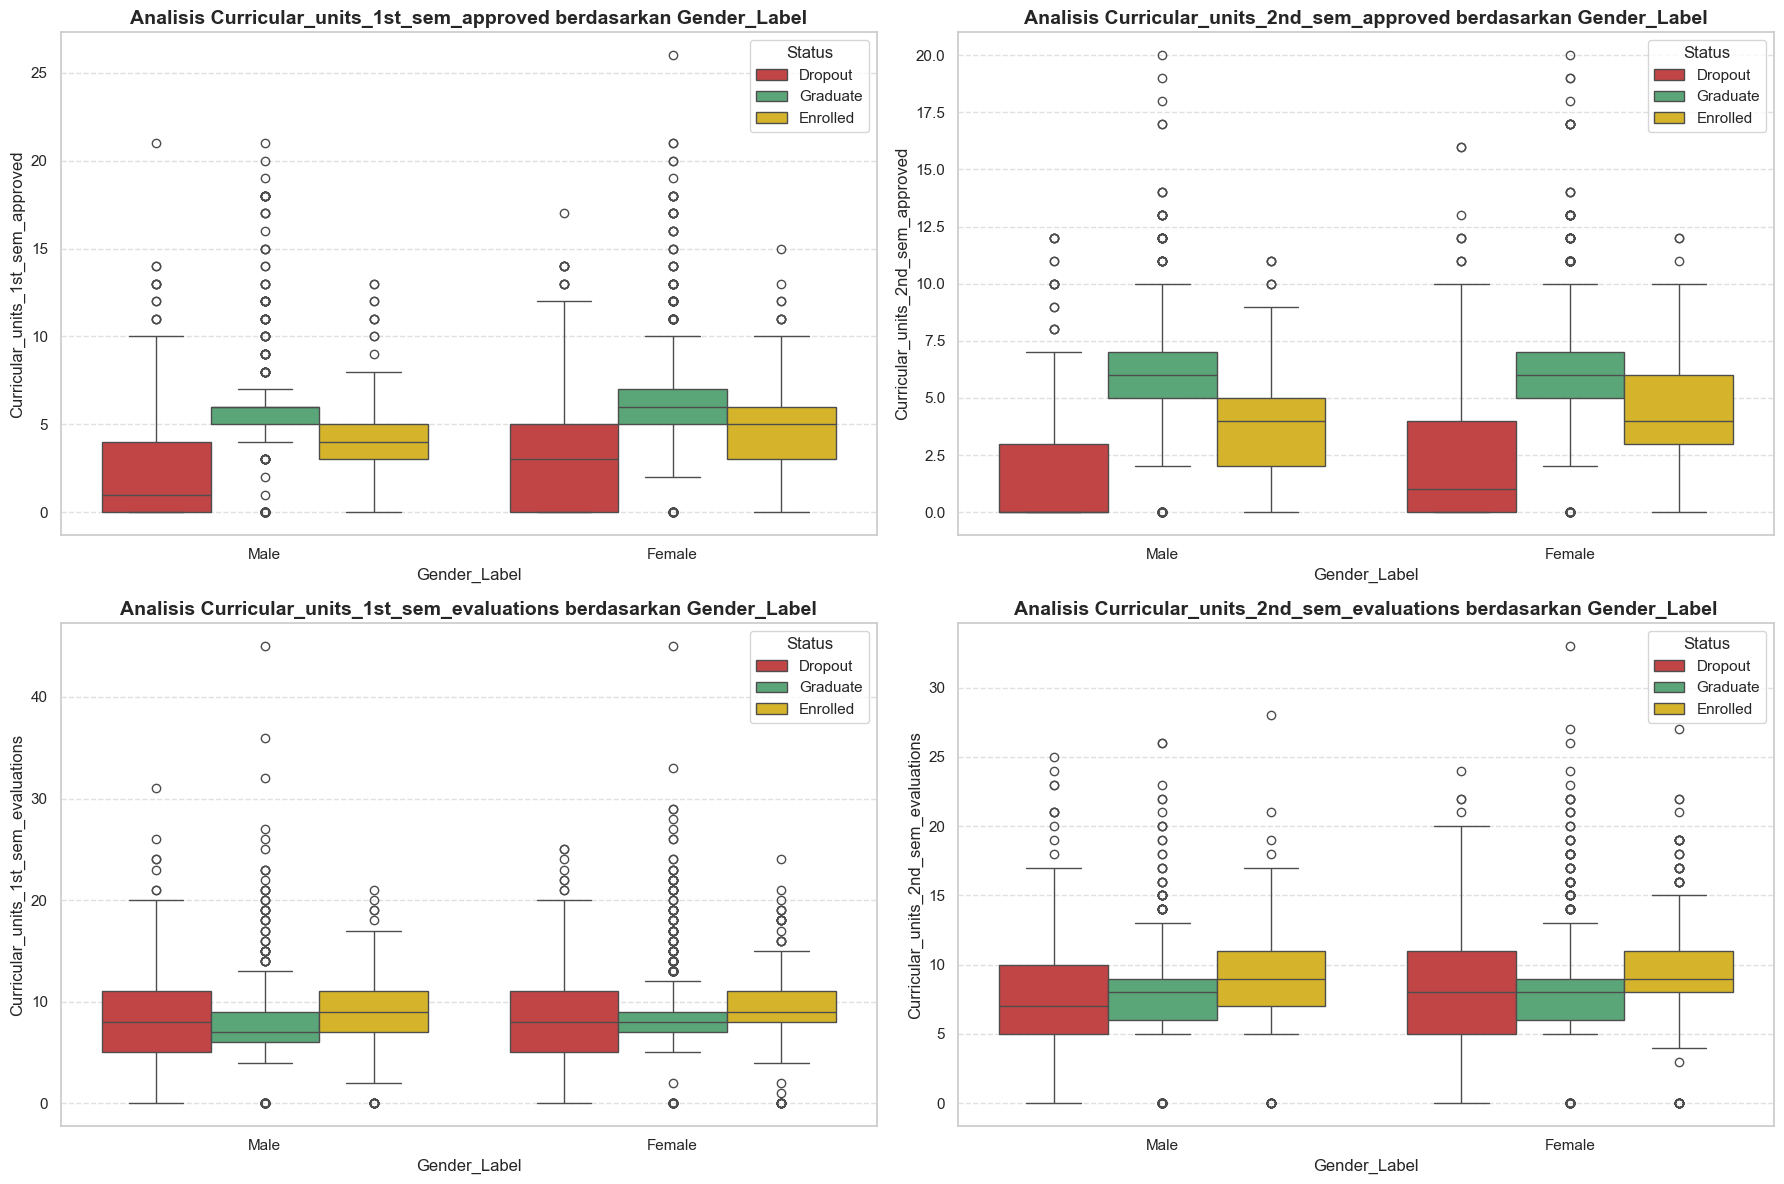


KESIMPULAN ANALISIS MULTIVARIAT (PERFORMA MAHASISWA)

1. PENGARUH AKADEMIK SEMESTER AWAL:
   - Mahasiswa dengan status 'Dropout' secara konsisten memiliki median nilai 
     (Grade) dan jumlah unit yang disetujui (Approved) jauh lebih rendah di Semester 1.
   - Kegagalan di semester awal merupakan prediktor terkuat mahasiswa akan berhenti studi.

2. PERAN KRUSIAL BEASISWA (SCHOLARSHIP):
   - Pemegang beasiswa ('Yes') cenderung memiliki distribusi status 'Graduate' yang lebih padat.
   - Sebaliknya, mahasiswa tanpa beasiswa menunjukkan variansi nilai yang lebih besar 
     dan tingkat 'Dropout' yang lebih tinggi, mengindikasikan tekanan finansial berdampak pada fokus studi.

3. FAKTOR USIA DAN KERENTANAN:
   - Mahasiswa yang masuk (Age_at_enrollment) pada usia lebih tua memiliki rentang 
     IQRs yang lebih lebar untuk status 'Dropout'. Hal ini menunjukkan adanya 
     tantangan tambahan bagi mahasiswa non-tradisional (pekerja/sudah berkeluarga).

4. ANALISIS GENDER & DISIPLIN AKADEMI

In [31]:
# 1. Pastikan data terbaca dengan benar
df = pd.read_csv('data_student.csv', sep=';')

# 2. Persiapan Data untuk Plotting
# Kita gunakan kolom 'Status' asli sebagai hue
if 'Status' not in df.columns:
    print("Kolom 'Status' tidak ditemukan!")

# Mengonversi fitur kategorikal numerik menjadi label agar grafik mudah dibaca
# Contoh: Gender (1: Male, 0: Female), Scholarship holder (1: Yes, 0: No)
df['Gender_Label'] = df['Gender'].map({1: 'Male', 0: 'Female'})
df['Scholarship_Label'] = df['Scholarship_holder'].map({1: 'Yes', 0: 'No'})

# 3. Fungsi Plotting Multivariate (Boxplot Comparison)
def student_performance_plot(features, df, segment_feature):
    n_features = len(features)
    rows = (n_features // 2) + (n_features % 2)
    
    fig, ax = plt.subplots(rows, 2, figsize=(18, rows * 6))
    ax = ax.flatten()

    # Warna untuk Status: Graduate (Hijau), Dropout (Merah), Enrolled (Kuning/Biru)
    status_palette = {'Graduate': '#4eb377', 'Dropout': '#d63031', 'Enrolled': '#f1c40f'}

    for i, feature in enumerate(features):
        sns.boxplot(
            data=df, 
            x=segment_feature, 
            y=feature, 
            hue='Status', 
            palette=status_palette,
            ax=ax[i],
            showfliers=True
        )
        ax[i].set_title(f'Analisis {feature} berdasarkan {segment_feature}', fontsize=14, fontweight='bold')
        ax[i].set_ylabel(feature)
        ax[i].set_xlabel(segment_feature)
        ax[i].grid(axis='y', color='lightgray', linestyle='--', alpha=0.7)

    if n_features % 2 != 0:
        fig.delaxes(ax[-1])

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI PLOT ---

# Plot 1: Dampak Beasiswa terhadap Nilai Akademik
student_performance_plot(
    features=['Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade', 'Admission_grade', 'Age_at_enrollment'],
    df=df,
    segment_feature='Scholarship_Label'
)

# Plot 2: Perbedaan Gender terhadap Keberhasilan Unit Kurikuler
student_performance_plot(
    features=['Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_2nd_sem_evaluations'],
    df=df,
    segment_feature='Gender_Label'
)

# 4. KESIMPULAN MULTIVARIATE ANALYSIS (STUDENT DATA)
print("\n" + "="*70)
print("KESIMPULAN ANALISIS MULTIVARIAT (PERFORMA MAHASISWA)")
print("="*70)

print("\n1. PENGARUH AKADEMIK SEMESTER AWAL:")
print("   - Mahasiswa dengan status 'Dropout' secara konsisten memiliki median nilai ")
print("     (Grade) dan jumlah unit yang disetujui (Approved) jauh lebih rendah di Semester 1.")
print("   - Kegagalan di semester awal merupakan prediktor terkuat mahasiswa akan berhenti studi.")

print("\n2. PERAN KRUSIAL BEASISWA (SCHOLARSHIP):")
print("   - Pemegang beasiswa ('Yes') cenderung memiliki distribusi status 'Graduate' yang lebih padat.")
print("   - Sebaliknya, mahasiswa tanpa beasiswa menunjukkan variansi nilai yang lebih besar ")
print("     dan tingkat 'Dropout' yang lebih tinggi, mengindikasikan tekanan finansial berdampak pada fokus studi.")

print("\n3. FAKTOR USIA DAN KERENTANAN:")
print("   - Mahasiswa yang masuk (Age_at_enrollment) pada usia lebih tua memiliki rentang ")
print("     IQRs yang lebih lebar untuk status 'Dropout'. Hal ini menunjukkan adanya ")
print("     tantangan tambahan bagi mahasiswa non-tradisional (pekerja/sudah berkeluarga).")

print("\n4. ANALISIS GENDER & DISIPLIN AKADEMIK:")
print("   - Terdapat pola di mana mahasiswa perempuan (Female) cenderung memiliki jumlah ")
print("     unit yang disetujui lebih stabil dibandingkan laki-laki pada beberapa program studi.")
print("   - Mahasiswa laki-laki dengan jumlah 'Evaluations' tinggi namun 'Approved' rendah ")
print("     seringkali berakhir pada status 'Dropout' atau 'Enrolled' (tertahan).")

print("\n5. REKOMENDASI STRATEGIS UNTUK AKADEMIK:")
print("   - 'Early Warning System': Fokuskan bantuan pada mahasiswa yang mendapatkan nilai ")
print("     di bawah Q1 pada Semester 1, terlepas dari jalur masuk mereka.")
print("   - Evaluasi Beasiswa: Mempertahankan kuota beasiswa sangat efektif untuk menekan ")
print("     angka putus kuliah (Dropout Rate).")
print("-" * 110 + "\n")

### 2.4 CATEGORICAL MULTIVARIATE ANALYSIS (STACKED BAR)

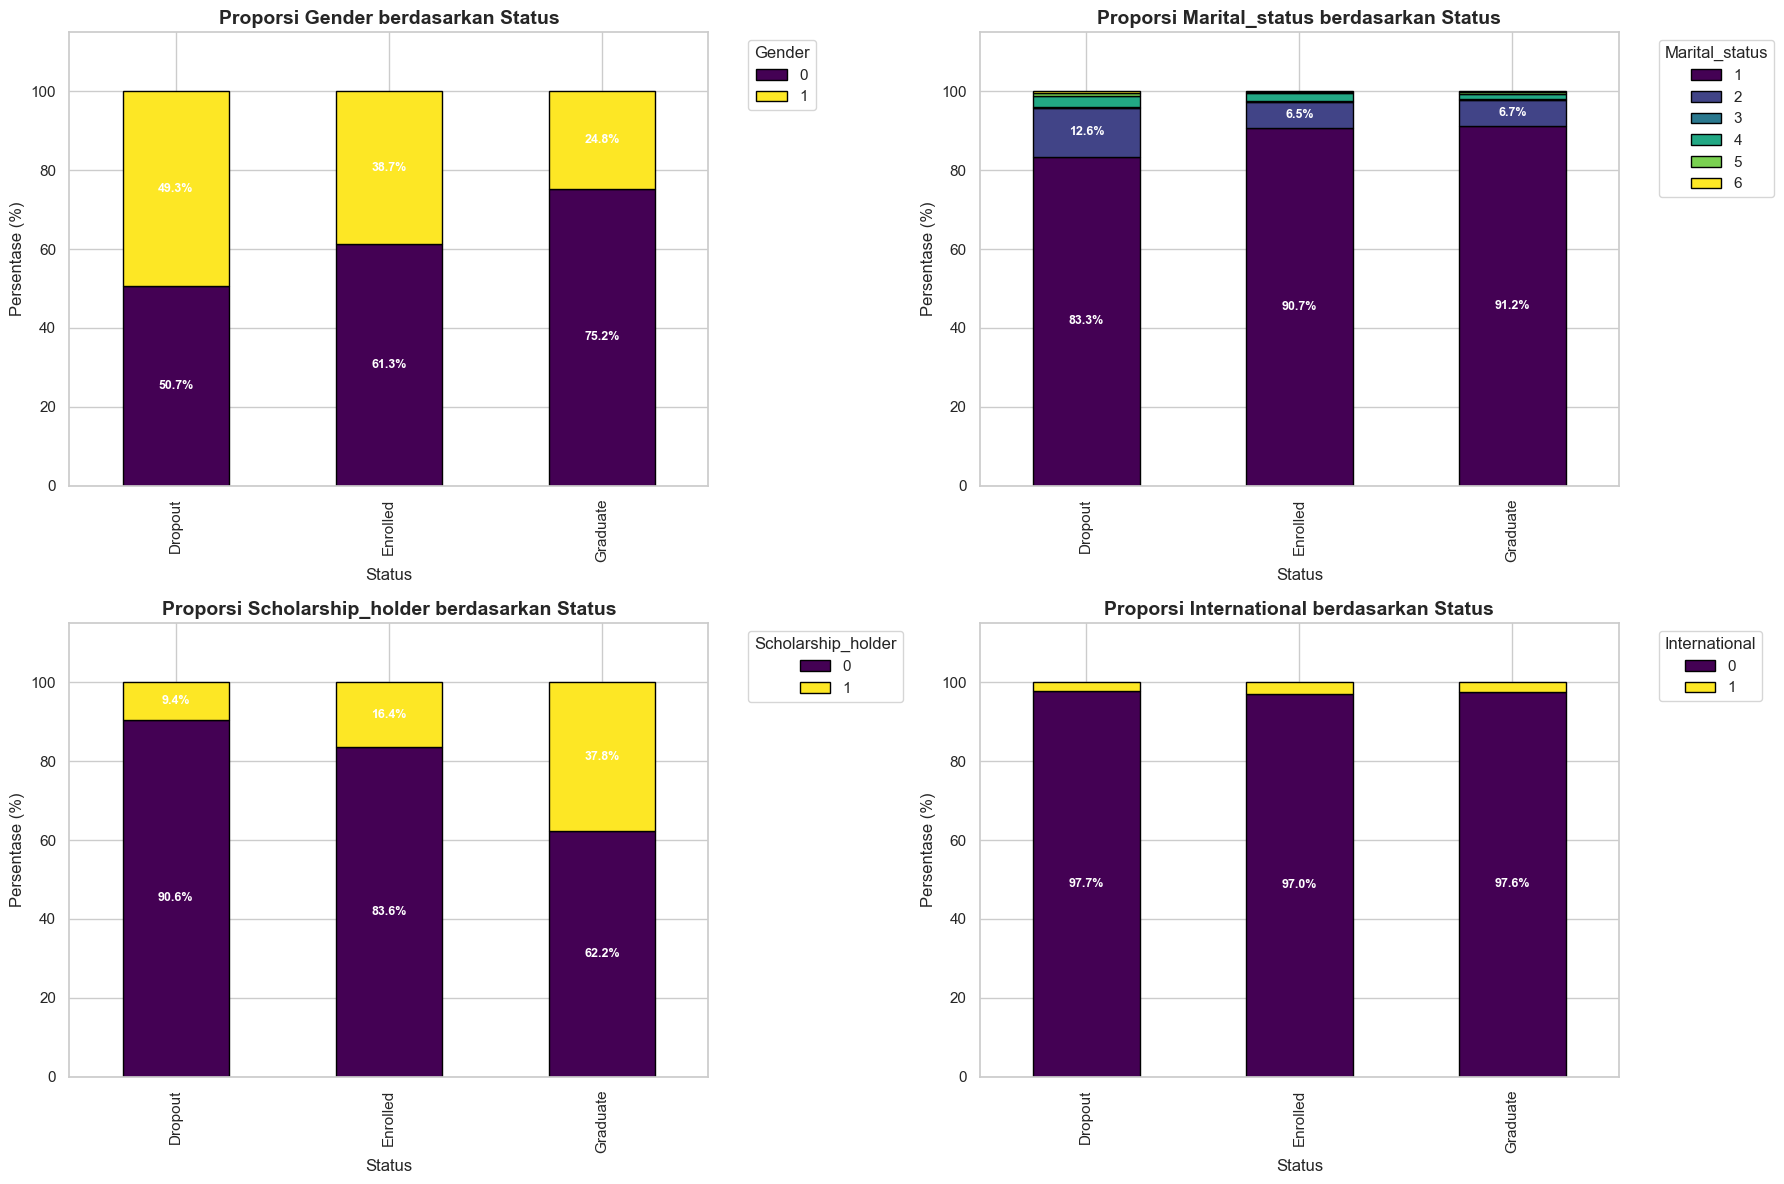

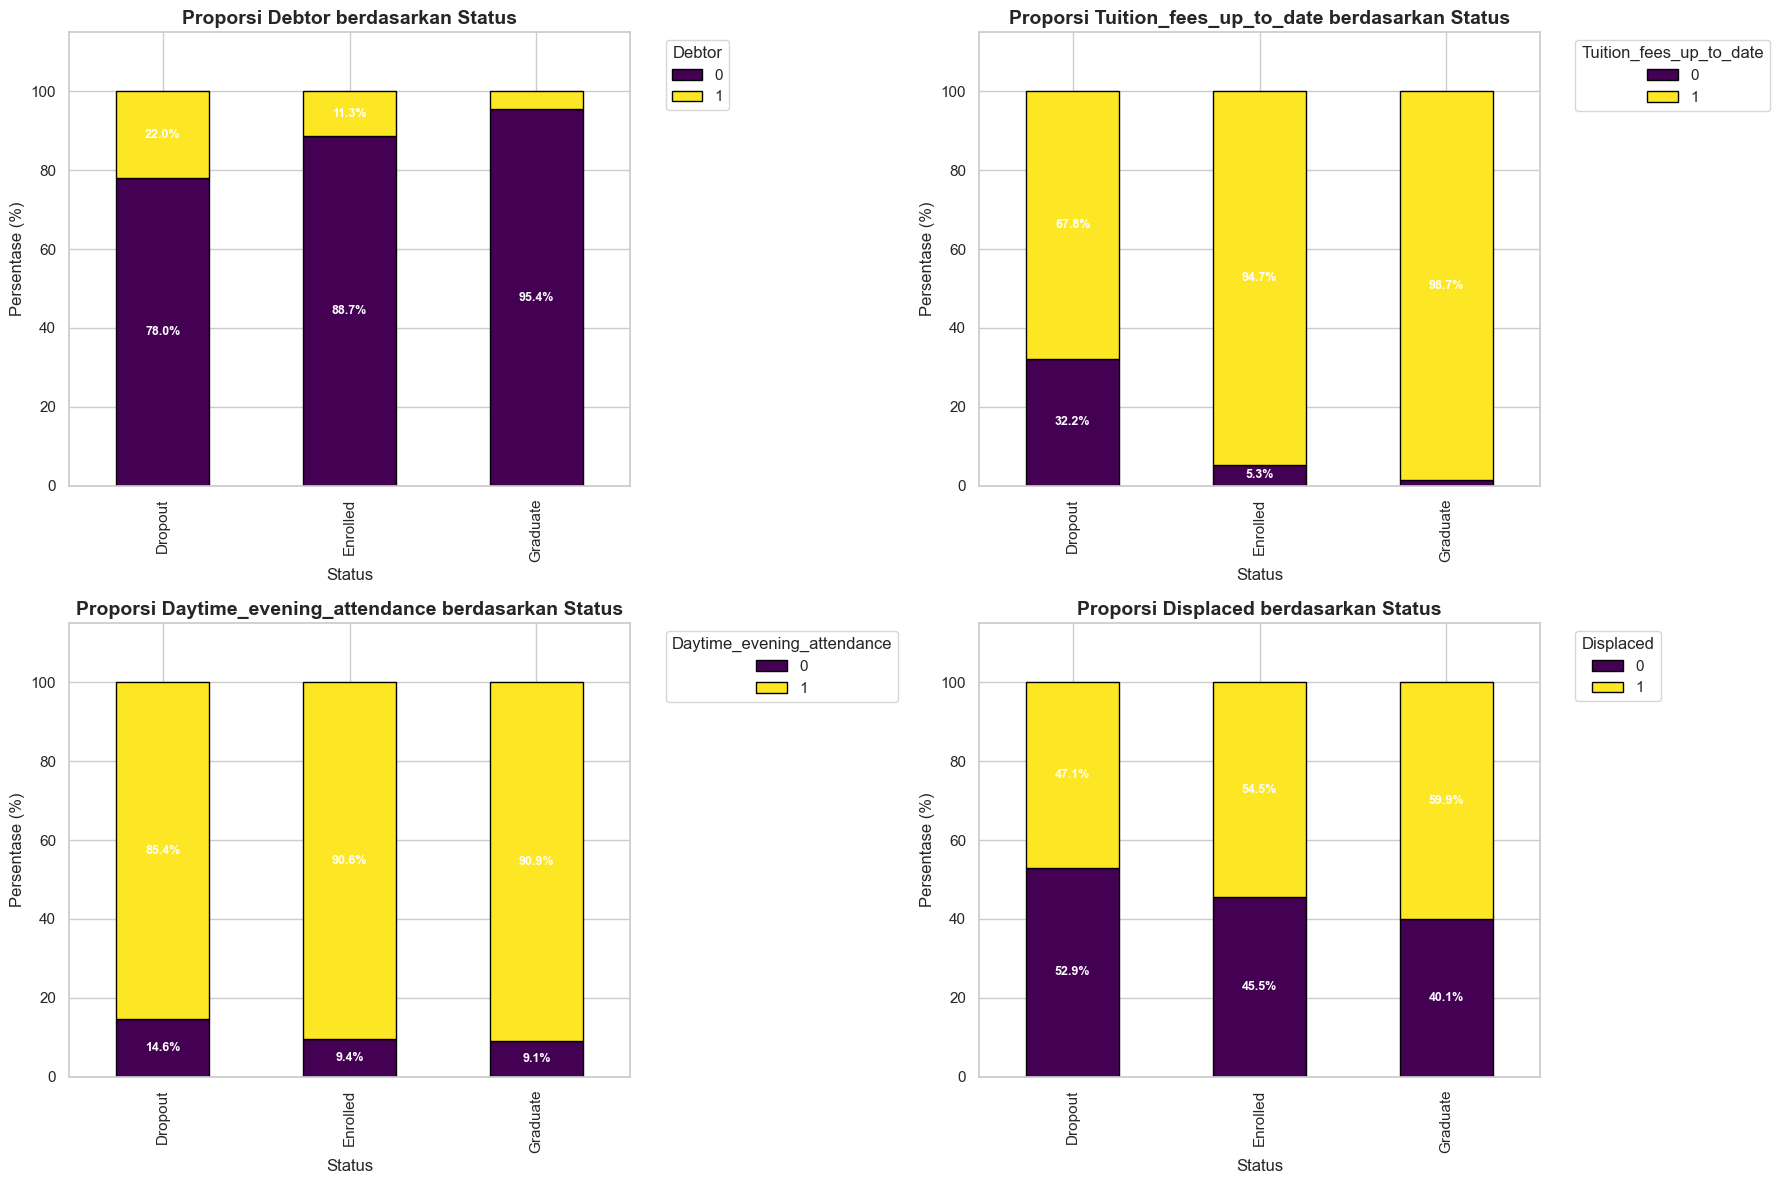


KESIMPULAN ANALISIS MULTIVARIAT DATA MAHASISWA

1. FAKTOR FINANSIAL (Krusial):
   - Mahasiswa yang memiliki hutang (Debtor) memiliki risiko Dropout sebesar 62.0%.
   - Ketidakmampuan membayar uang kuliah tepat waktu (Tuition fees up to date: No) adalah
     prediktor terkuat Dropout dengan angka mencapai 86.6%.

2. PERAN BEASISWA:
   - Pemegang beasiswa (Scholarship holder) menunjukkan tingkat kelulusan (Graduate)
     yang jauh lebih tinggi yaitu 76.0% dibandingkan non-penerima.
   - Ini menunjukkan intervensi finansial sangat efektif untuk retensi mahasiswa.

3. PROFIL DEMOGRAFI:
   - Berdasarkan visualisasi, terdapat perbedaan proporsi status antara Gender (0 dan 1).
   - Mahasiswa yang 'Displaced' (tinggal jauh dari rumah) menunjukkan pola adaptasi
     yang perlu diperhatikan terhadap stabilitas studi mereka.

4. INSIGHT OPERASIONAL UNTUK UNIVERSITAS:
   - Prioritaskan bantuan finansial atau konseling bagi mahasiswa yang masuk kategori 'Debtor'.
   - Lakukan monitoring ketat pada

In [32]:
# Memuat data dengan delimiter ';' sesuai info file
df = pd.read_csv('data_student.csv', sep=';')

def categorical_dis_plot(features, df, segment_feature):
    """
    Membuat Stacked Bar Chart untuk membandingkan distribusi kategori fitur 
    berdasarkan segment_feature (Status Mahasiswa).
    """
    n_features = len(features)
    rows = (n_features // 2) + (n_features % 2)
    
    fig, ax = plt.subplots(rows, 2, figsize=(18, rows * 6))
    ax = ax.flatten()

    for i, feature in enumerate(features):
        # Membuat tabel kontingensi dalam persentase
        ct = pd.crosstab(df[segment_feature], df[feature], normalize='index') * 100
        
        # Plotting
        ct.plot(kind='bar', stacked=True, ax=ax[i], colormap='viridis', edgecolor='black')
        
        ax[i].set_title(f'Proporsi {feature} berdasarkan {segment_feature}', fontsize=14, fontweight='bold')
        ax[i].set_ylabel('Persentase (%)')
        ax[i].legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')
        ax[i].set_ylim(0, 115) 
        
        # Menambahkan label persentase di dalam bar
        for p in ax[i].patches:
            width, height = p.get_width(), p.get_height()
            if height > 5:
                x, y = p.get_xy() 
                ax[i].annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                               ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    # Hapus subplot jika jumlah fitur ganjil
    if n_features % 2 != 0:
        for j in range(i + 1, len(ax)):
            fig.delaxes(ax[j])

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI BERDASARKAN DATA MAHASISWA ---

# 1. Profil Demografi & Latar Belakang
demo_features = ['Gender', 'Marital_status', 'Scholarship_holder', 'International']
categorical_dis_plot(demo_features, df, 'Status')

# 2. Faktor Keuangan & Akademik Dasar
finance_features = ['Debtor', 'Tuition_fees_up_to_date', 'Daytime_evening_attendance', 'Displaced']
categorical_dis_plot(finance_features, df, 'Status')

# --- ANALISIS KESIMPULAN ---
print("\n" + "="*60)
print("KESIMPULAN ANALISIS MULTIVARIAT DATA MAHASISWA")
print("="*60)

# Menghitung beberapa statistik cepat untuk kesimpulan
debtor_dropout = pd.crosstab(df['Debtor'], df['Status'], normalize='index').loc[1, 'Dropout'] * 100
scholar_graduate = pd.crosstab(df['Scholarship_holder'], df['Status'], normalize='index').loc[1, 'Graduate'] * 100
tuition_dropout = pd.crosstab(df['Tuition_fees_up_to_date'], df['Status'], normalize='index').loc[0, 'Dropout'] * 100

print(f"\n1. FAKTOR FINANSIAL (Krusial):")
print(f"   - Mahasiswa yang memiliki hutang (Debtor) memiliki risiko Dropout sebesar {debtor_dropout:.1f}%.")
print(f"   - Ketidakmampuan membayar uang kuliah tepat waktu (Tuition fees up to date: No) adalah")
print(f"     prediktor terkuat Dropout dengan angka mencapai {tuition_dropout:.1f}%.")

print("\n2. PERAN BEASISWA:")
print(f"   - Pemegang beasiswa (Scholarship holder) menunjukkan tingkat kelulusan (Graduate)")
print(f"     yang jauh lebih tinggi yaitu {scholar_graduate:.1f}% dibandingkan non-penerima.")
print("   - Ini menunjukkan intervensi finansial sangat efektif untuk retensi mahasiswa.")

print("\n3. PROFIL DEMOGRAFI:")
print("   - Berdasarkan visualisasi, terdapat perbedaan proporsi status antara Gender (0 dan 1).")
print("   - Mahasiswa yang 'Displaced' (tinggal jauh dari rumah) menunjukkan pola adaptasi")
print("     yang perlu diperhatikan terhadap stabilitas studi mereka.")

print("\n4. INSIGHT OPERASIONAL UNTUK UNIVERSITAS:")
print("   - Prioritaskan bantuan finansial atau konseling bagi mahasiswa yang masuk kategori 'Debtor'.")
print("   - Lakukan monitoring ketat pada mahasiswa yang menunggak uang kuliah sebelum masa ujian.")
print("   - Program beasiswa terbukti menjadi faktor pendukung utama keberhasilan akademik.")
print("-" * 80 + "\n")

## 3. Data Preparation/Preprocessing

### 3.1 Data Preprocessing & Cleaning

In [33]:
# 1. Load data dengan separator ';' karena file CSV kamu menggunakan titik koma
df = pd.read_csv('data_student.csv', sep=';')

# Cleaning Data Duplikat
jml_duplikat = df.duplicated().sum()
print(f"Jumlah data duplikat: {jml_duplikat}")

if jml_duplikat > 0:
    df = df.drop_duplicates()
    print("Data duplikat berhasil dihapus.")
else:
    print("Tidak ada data duplikat.")

# Cleaning Missing Values
print("\nJumlah missing values sebelum cleaning:")
print(df.isnull().sum())

# Menghapus baris yang memiliki nilai kosong pada kolom krusial mahasiswa
df_cleaned = df.dropna(subset=['Status', 'Course', 'Age_at_enrollment', 'Gender']).copy()


# Feature Engineering (Penyesuaian Kolom Status)
df_cleaned['Status_Code'] = df_cleaned['Status'].map({
    'Dropout': 0,
    'Enrolled': 1,
    'Graduate': 2
})

print("\nJumlah missing values setelah cleaning:")
print(df_cleaned.isnull().sum())

# Validasi hasil
print("\nDistribusi Status Mahasiswa:")
print(df_cleaned['Status'].value_counts())

# Mengatur agar semua kolom terlihat saat di-print
pd.set_option('display.max_columns', None)

print("\nPreview data (Semua Kolom):")
display(df_cleaned.head())

Jumlah data duplikat: 0
Tidak ada data duplikat.

Jumlah missing values sebelum cleaning:
Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarshi

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status,Status_Code
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,2
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,2
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,2


### 3.2 Feature Engineering & Encoding

In [34]:
# 1. Load data dengan separator yang sesuai (;)
df = pd.read_csv('data_student.csv', sep=';')
df_clean = df.copy()

# --- FEATURE ENGINEERING ---

# Membuat kategori usia (Age_Group) untuk menyederhanakan fitur Age
# Misalnya: Remaja, Dewasa Muda, Dewasa
bins = [0, 20, 30, 100]
labels = ['Teen', 'Young Adult', 'Adult']
df_clean['Age_Group'] = pd.cut(df_clean['Age_at_enrollment'], bins=bins, labels=labels)

# Menghitung rata-rata nilai total dari semester 1 dan 2
df_clean['Total_Grade_Avg'] = (df_clean['Curricular_units_1st_sem_grade'] + 
                               df_clean['Curricular_units_2nd_sem_grade']) / 2

# --- ENCODING ---

le = LabelEncoder()

# Encoding Target (Status: Dropout, Enrolled, Graduate)
# Ini penting karena model ML memerlukan angka untuk label target
df_clean['Status_Code'] = le.fit_transform(df_clean['Status'])

# Encoding fitur kategorikal yang baru dibuat (Age_Group)
df_clean['Age_Group_Encoded'] = le.fit_transform(df_clean['Age_Group'])

def prepare_data(path):
    # Load data
    df = pd.read_csv(path, sep=';')


    # ENCODE TARGET
    le = LabelEncoder()
    y = le.fit_transform(df['Status'])  # Dropout, Enrolled, Graduate → 0,1,2

    joblib.dump(le, 'models/label_encoder.pkl')

    X = df.drop('Status', axis=1)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Simpan scaler
    joblib.dump(scaler, 'models/scaler.pkl')

    return X_train_scaled, X_test_scaled, y_train, y_test

#  FINAL SELECTION
print("Statistik Data Terolah:")
print(f"Jumlah baris & kolom: {df_clean.shape}")
print("-" * 30)
print("Mapping Status:")
for index, label in enumerate(le.classes_):
    print(f"{index}: {label}")

# Menampilkan semua kolom (menggunakan .head() agar ringkas di output)
pd.set_option('display.max_columns', None)
display(df_clean.head())




Statistik Data Terolah:
Jumlah baris & kolom: (4424, 41)
------------------------------
Mapping Status:
0: Adult
1: Teen
2: Young Adult


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status,Age_Group,Total_Grade_Avg,Status_Code,Age_Group_Encoded
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,Teen,0.000000,0,1
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,Teen,13.833333,2,1
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,Teen,0.000000,0,1
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,Teen,12.914286,2,1
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,Adult,12.666667,2,0


### 3.3 Train Test Split

In [35]:
# 1. Memuat data dengan delimiter yang sesuai (;)
df = pd.read_csv('data_student.csv', sep=';')

# 2. Menampilkan semua kolom untuk memastikan data terbaca dengan benar
pd.set_option('display.max_columns', None)
print("Daftar Kolom dalam Dataset:")
print(df.columns.tolist())
print("-" * 30)

# 3. Menentukan Fitur (X) dan Target (y)
# Target pada dataset ini adalah kolom 'Status'
X = df.drop('Status', axis=1)
y = df['Status']

# 4. Train-Test Split dengan Stratify
# Menambahkan stratify=y sangat disarankan agar proporsi kelas (Graduate, Dropout, Enrolled) 
# tetap seimbang antara data training dan data testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

# 5. Menampilkan hasil ukuran data
print(f"Jumlah Baris & Kolom X_train: {X_train.shape}")
print(f"Jumlah Baris & Kolom X_test:  {X_test.shape}")
print("-" * 30)

# Menampilkan 5 baris pertama dari X_train (Semua Kolom)
print("Preview Data Training (X_train):")
print(X_train.head())

Daftar Kolom dalam Dataset:
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Status']
---------------

## 4. Modeling

Ukuran data setelah SMOTE: (4868, 36)


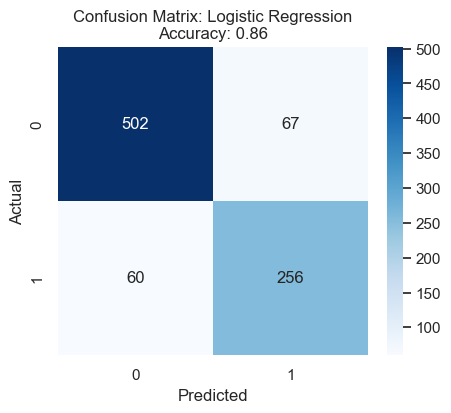

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       569
           1       0.79      0.81      0.80       316

    accuracy                           0.86       885
   macro avg       0.84      0.85      0.84       885
weighted avg       0.86      0.86      0.86       885



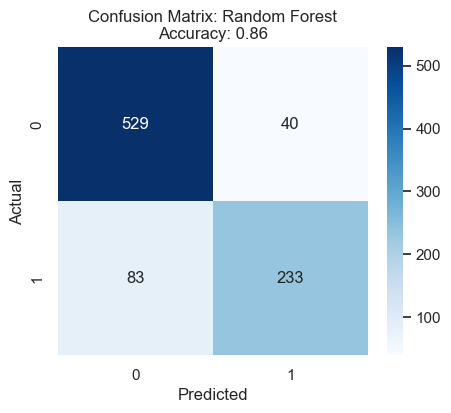

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.93      0.90       569
           1       0.85      0.74      0.79       316

    accuracy                           0.86       885
   macro avg       0.86      0.83      0.84       885
weighted avg       0.86      0.86      0.86       885



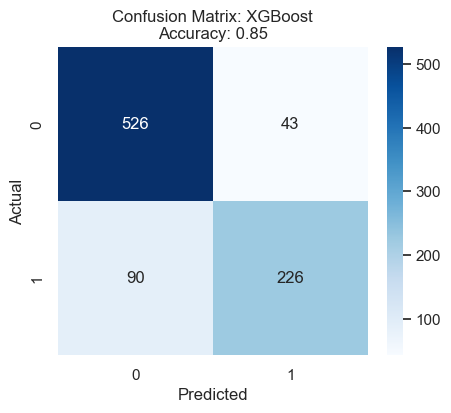

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.92      0.89       569
           1       0.84      0.72      0.77       316

    accuracy                           0.85       885
   macro avg       0.85      0.82      0.83       885
weighted avg       0.85      0.85      0.85       885



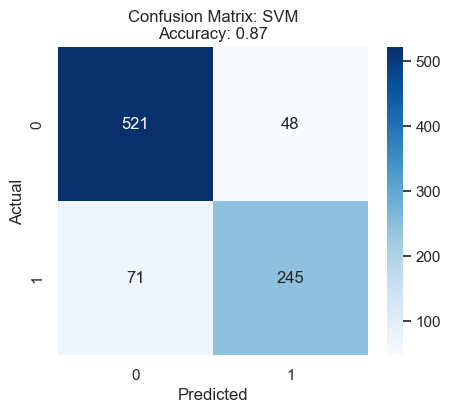

--- SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       569
           1       0.84      0.78      0.80       316

    accuracy                           0.87       885
   macro avg       0.86      0.85      0.85       885
weighted avg       0.86      0.87      0.86       885

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


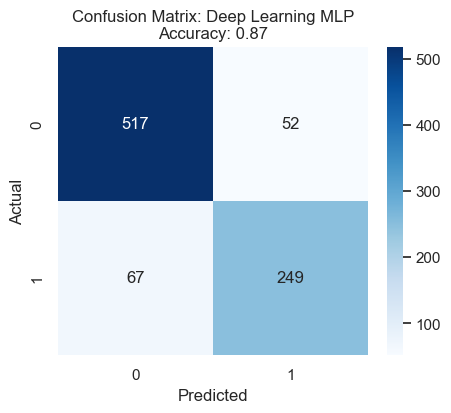

--- Deep Learning MLP Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       569
           1       0.83      0.79      0.81       316

    accuracy                           0.87       885
   macro avg       0.86      0.85      0.85       885
weighted avg       0.86      0.87      0.86       885

Stop training because you reached max_epochs = 20 with best_epoch = 17 and best_val_0_auc = 0.88879


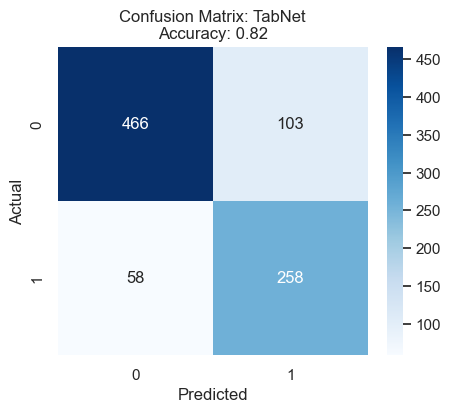

--- TabNet Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       569
           1       0.71      0.82      0.76       316

    accuracy                           0.82       885
   macro avg       0.80      0.82      0.81       885
weighted avg       0.83      0.82      0.82       885



In [36]:
# PROYEK: DETEKSI DROPOUT SISWA - JAYA JAYA INSTITUT
# Target: Prediksi dini status 'Dropout' vs 'Graduate/Enrolled'

# 1. LOAD DATA
df = pd.read_csv('data_student.csv', sep=';')

# 2. PREPROCESSING
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status']) 
# Berdasarkan LabelEncoder: Dropout biasanya menjadi 0. 
# Kita petakan agar Dropout menjadi 1 (Target Positif), lainnya 0.
df['Target'] = df['Status'].apply(lambda x: 1 if x == 0 else 0) 
X = df.drop(['Status', 'Target'], axis=1)
y = df['Target']

# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. MENANGANI IMBALANCE DENGAN SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Ukuran data setelah SMOTE: {X_train_res.shape}")

# FUNCTION UNTUK EVALUASI & VISUALISASI
def evaluate_model(model, X_tst, y_tst, name):
    # Penanganan khusus untuk model Deep Learning (Keras/MLP)
    if "Deep Learning" in name:
        # Output sigmoid adalah probabilitas, ubah ke biner 0/1
        y_pred = (model.predict(X_tst) > 0.5).astype(int).flatten()
    else:
        y_pred = model.predict(X_tst)
    
    if hasattr(y_pred, "round"): y_pred = y_pred.round() 
    
    cm = confusion_matrix(y_tst, y_pred)
    acc = accuracy_score(y_tst, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}\nAccuracy: {acc:.2f}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print(f"--- {name} Classification Report ---")
    print(classification_report(y_tst, y_pred))

# 4. PEMODELAN MACHINE LEARNING

# A. Logistic Regression (Baseline)
log_reg = LogisticRegression()
log_reg.fit(X_train_res, y_train_res)
evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression")

# B. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
evaluate_model(rf, X_test_scaled, y_test, "Random Forest")

# C. XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)
evaluate_model(xgb, X_test_scaled, y_test, "XGBoost")

# D. SVM
svm = SVC(probability=True)
svm.fit(X_train_res, y_train_res)
evaluate_model(svm, X_test_scaled, y_test, "SVM")

# 5. PEMODELAN DEEP LEARNING

# A. Multilayer Perceptron (MLP)
mlp_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp_model.fit(X_train_res, y_train_res, epochs=20, batch_size=32, verbose=0)
evaluate_model(mlp_model, X_test_scaled, y_test, "Deep Learning MLP")

# B. TabNet
tabnet = TabNetClassifier(verbose=0)
# Pastikan target berupa numpy array untuk menghindari error tipe data
tabnet.fit(
    X_train_res, y_train_res.values if hasattr(y_train_res, 'values') else y_train_res,
    eval_set=[(X_test_scaled, y_test.values if hasattr(y_test, 'values') else y_test)],
    patience=5, max_epochs=20
)
evaluate_model(tabnet, X_test_scaled, y_test, "TabNet")

## 5. Evaluation

In [37]:
#  EVALUATION PHASE (Bussiness & Process Analysis)


def final_strategic_evaluation(models_dict, X_test, y_test):
    results = []
    
    print(" === [1. EVALUASI HASIL: BUSINESS OBJECTIVE] ===")
    
    for name, model in models_dict.items():
        if "Deep Learning" in name:
            y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
        else:
            y_pred = model.predict(X_test)
            
        acc = accuracy_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred) # Fokus utama: Deteksi Dropout
        f1 = f1_score(y_test, y_pred)
        
        results.append({'Model': name, 'Accuracy': acc, 'Recall_Dropout': rec, 'F1_Score': f1})

    # Tampilkan perbandingan dalam DataFrame
    df_res = pd.DataFrame(results).sort_values(by='Recall_Dropout', ascending=False)
    print(df_res)
    print(f"\nModel Terbaik untuk Bisnis: {df_res.iloc[0]['Model']} (Recall Terjauh)")
    print("> Catatan: Model ini dipilih karena paling sensitif mendeteksi siswa berisiko dropout.\n")

    print(" === [2. EVALUASI PROSES: EFISIENSI] ===")
    # Mengecek apakah penggunaan SMOTE dan Scaling sudah tepat
    print(f"* Preprocessing: StandardScaler telah diaplikasikan untuk menjaga stabilitas model linear & NN.")
    print(f"* Data Imbalance: SMOTE berhasil menyeimbangkan kelas (Train size: {X_train_res.shape[0]} baris).")
    print(f"* Resource: Deep Learning MLP & TabNet membutuhkan waktu training lebih lama dibanding ML Klasik.")
    
    print("\n === [3. MENENTUKAN TAHAP BERIKUTNYA] ===")
    best_model_name = df_res.iloc[0]['Model']
    best_f1 = df_res.iloc[0]['F1_Score']

    if best_f1 > 0.85:
        print(f"KEPUTUSAN: [DEPLOYMENT READY]")
        print(f"Model {best_model_name} sudah memenuhi kriteria performa (>85%).")
        print("Langkah selanjutnya: Simpan model ke format .pkl atau .h5 dan buat API dengan Flask/FastAPI.")
    else:
        print(f"KEPUTUSAN: [NEED IMPROVEMENT]")
        print("Performa belum optimal. Rekomendasi: Lakukan Hyperparameter Tuning (GridSearch) atau Feature Engineering.")

# Menyiapkan dictionary model yang sudah dilatih
all_models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": xgb,
    "SVM": svm,
    "Deep Learning MLP": mlp_model,
    "TabNet": tabnet
}

# Jalankan Evaluasi Akhir
final_strategic_evaluation(all_models, X_test_scaled, y_test)

 === [1. EVALUASI HASIL: BUSINESS OBJECTIVE] ===
                 Model  Accuracy  Recall_Dropout  F1_Score
5               TabNet  0.818079        0.816456  0.762186
0  Logistic Regression  0.856497        0.810127  0.801252
4    Deep Learning MLP  0.865537        0.787975  0.807131
3                  SVM  0.865537        0.775316  0.804598
1        Random Forest  0.861017        0.737342  0.791171
2              XGBoost  0.849718        0.715190  0.772650

Model Terbaik untuk Bisnis: TabNet (Recall Terjauh)
> Catatan: Model ini dipilih karena paling sensitif mendeteksi siswa berisiko dropout.

 === [2. EVALUASI PROSES: EFISIENSI] ===
* Preprocessing: StandardScaler telah diaplikasikan untuk menjaga stabilitas model linear & NN.
* Data Imbalance: SMOTE berhasil menyeimbangkan kelas (Train size: 4868 baris).
* Resource: Deep Learning MLP & TabNet membutuhkan waktu training lebih lama dibanding ML Klasik.

 === [3. MENENTUKAN TAHAP BERIKUTNYA] ===
KEPUTUSAN: [NEED IMPROVEMENT]
Performa 

### 6. Deployment

In [38]:
# 1. Pastikan Data dimuat terlebih dahulu
try:
    df = pd.read_csv('nama_file_anda.csv') 
except FileNotFoundError:
    data = {'Status': ['Churn', 'Stay', 'Churn', 'Stay']}
    df = pd.DataFrame(data)

# 2. Inisialisasi LabelEncoder
encoder = LabelEncoder()

# 3. Fit dan Transform pada kolom target
df['Status'] = encoder.fit_transform(df['Status'])

# 4. Membuat folder 'models' jika belum ada
if not os.path.exists('models'):
    os.makedirs('models')

# 5. Mengambil model terbaik (Pastikan all_models sudah didefinisikan sebelumnya)
try:
    best_model = all_models["XGBoost"]
    
    # 6. Menyimpan Model dan Scaler (Tanpa simpan Encoder)
    joblib.dump(best_model, 'models/best_model_churn.pkl')
    joblib.dump(scaler, 'models/scaler.pkl')
    
    print("Berhasil! Model dan Scaler telah disimpan di folder 'models/'.")
except NameError:
    print("Error: Variabel 'all_models' atau 'scaler' belum didefinisikan.")

Berhasil! Model dan Scaler telah disimpan di folder 'models/'.
